In [3]:
# 导入必要的库
import matplotlib as mpl
import matplotlib.pyplot as plt
# 在Jupyter notebook中内联显示图表
%matplotlib inline
import numpy as np
import sklearn
import pandas as pd
import os
import sys
import time
from tqdm.auto import tqdm  # 进度条库
import torch
import torch.nn as nn
import torch.nn.functional as F

# 打印Python版本信息
print(sys.version_info)

# 打印各个库的版本信息
for module in mpl, np, pd, sklearn, torch:
    print(module.__name__, module.__version__)

# 设置设备：如果有GPU则使用GPU，否则使用CPU
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)


sys.version_info(major=3, minor=12, micro=12, releaselevel='final', serial=0)
matplotlib 3.10.8
numpy 2.3.5
pandas 2.3.3
sklearn 1.8.0
torch 2.9.1+cu128
cuda:0


# 数据预处理

In [4]:
from pathlib import Path

DATA_DIR = Path("./competitions/cifar-10")

train_lables_file = DATA_DIR / "trainLabels.csv"
test_csv_file = DATA_DIR / "sampleSubmission.csv" #测试集模板csv文件
train_folder = DATA_DIR / "train"
test_folder = DATA_DIR / "test"


#所有的类别
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck',
]
# INSERT_YOUR_CODE
import pandas as pd

def load_image_paths_and_labels(labels_csv_path, images_folder):
    """
    读取labels_csv_path（trainLabels.csv），为每张图片拼接完整路径，并返回[(img_path, label), ...]的列表
    """
    df = pd.read_csv(labels_csv_path)
    items = []
    for idx, row in df.iterrows():
        img_name = row['id']  # 假设csv第一列是id（去掉.jpg后缀的文件名）
        label = row['label']
        img_path = images_folder / f"{img_name}.png"  # cifar10可能是png，也可能是jpg，请确保格式一致
        if not img_path.exists():
            img_path = images_folder / f"{img_name}.jpg"
        items.append( (str(img_path), label) )
    return items

# 示例调用方法
train_items = load_image_paths_and_labels(train_lables_file, train_folder)
# test_items = load_image_paths_and_labels(test_csv_file, test_folder)

import pprint
pprint.pprint(train_items[:5])



[('competitions/cifar-10/train/1.png', 'frog'),
 ('competitions/cifar-10/train/2.png', 'truck'),
 ('competitions/cifar-10/train/3.png', 'truck'),
 ('competitions/cifar-10/train/4.png', 'deer'),
 ('competitions/cifar-10/train/5.png', 'automobile')]


In [5]:
# INSERT_YOUR_CODE
import pandas as pd

# 将train_items分为45000条用于训练，5000条用于验证
train_items_ = train_items[:45000]
valid_items_ = train_items[45000:]

# 转为DataFrame
train_df = pd.DataFrame(train_items_, columns=["img_path", "label"])
valid_df = pd.DataFrame(valid_items_, columns=["img_path", "label"])
# test_df = pd.DataFrame(test_items, columns=["img_path", "label"])


In [6]:
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class Cifar10Dataset(Dataset):
    df_map = {
        "train": train_df,
        "eval": valid_df,
    }
    label_to_idx = {label: idx for idx, label in enumerate(class_names)} # 类别映射为idx
    idx_to_label = {idx: label for idx, label in enumerate(class_names)} # idx映射为类别,为了test使用
    def __init__(self, mode, transform=None):
        self.df = self.df_map.get(mode, None) # 获取对应模式的df，不同字符串对应不同模式
        if self.df is None:
            raise ValueError("mode should be one of train, val, test, but got {}".format(mode))
        # assert self.df, "df is None"
        self.transform = transform

    def __getitem__(self, index):
        img_path, label = self.df.iloc[index] # 获取图片路径和标签
        img = Image.open(img_path).convert('RGB')
        # # img 转换为 channel first
        # img = img.transpose((2, 0, 1))
        # transform
        img = self.transform(img) # 数据增强
        # label 转换为 idx
        label = self.label_to_idx[label]
        return img, label

    def __len__(self):
        return self.df.shape[0] # 返回df的行数,样本数

IMAGE_SIZE = 32
mean, std = [0.4914, 0.4822, 0.4465], [0.247, 0.243, 0.261]

transforms_train = transforms.Compose([
        # resize
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)), #缩放
        # random rotation 40
        transforms.RandomRotation(40), #随机旋转
        # horizaontal flip
        transforms.RandomHorizontalFlip(),  #随机水平翻转
        transforms.ToTensor(), #转换为tensor
        transforms.Normalize(mean, std) #标准化
    ]) #数据增强

transforms_eval = transforms.Compose([
        # resize
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])
# ToTensor还将图像的维度从[height, width, channels]转换为[channels, height, width]。
train_ds = Cifar10Dataset("train", transforms_train)
eval_ds = Cifar10Dataset("eval", transforms_eval)

In [7]:

# 对train_ds计算均值和标准差
# from torch.utils.data import DataLoader
# import torch
#
# loader = DataLoader(train_ds, batch_size=64, shuffle=False, num_workers=2)
#
# mean = torch.zeros(3)
# std = torch.zeros(3)
# n_pixels = 0
#
# for images, _ in loader:  # images: [B, 3, H, W]
#     batch_pixels = images.shape[0] * images.shape[2] * images.shape[3]
#     mean += images.sum([0, 2, 3])
#     std += (images ** 2).sum([0, 2, 3])
#     n_pixels += batch_pixels
#
# mean /= n_pixels
# std = torch.sqrt(std / n_pixels - mean ** 2)
#
# print("train_ds按通道均值:", mean)
# print("train_ds按通道标准差:", std)



In [8]:
from torch.utils.data import DataLoader

# 创建训练集和验证集的DataLoader
batch_size = 32

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,  # 训练时打乱数据
)

test_loader = DataLoader(
    eval_ds,
    batch_size=batch_size,
    shuffle=False,  # 测试时不需要打乱
)

print(f"训练集DataLoader批次数: {len(train_loader)}")
print(f"测试集DataLoader批次数: {len(test_loader)}")
print(f"每个批次大小: {batch_size}")

# 查看一个批次的数据
for batch_images, batch_labels in train_loader:
    print(f"批次图像张量形状: {batch_images.shape}")
    print(f"批次标签张量形状: {batch_labels.shape}")
    print(batch_labels)
    break

训练集DataLoader批次数: 1407
测试集DataLoader批次数: 157
每个批次大小: 32
批次图像张量形状: torch.Size([32, 3, 32, 32])
批次标签张量形状: torch.Size([32])
tensor([2, 4, 1, 9, 8, 5, 5, 9, 3, 5, 7, 8, 5, 4, 0, 4, 1, 8, 7, 0, 0, 1, 2, 8,
        1, 3, 5, 7, 2, 8, 0, 6])


# 搭建模型

In [9]:
import torch  # 导入pytorch主模块
import torch.nn as nn  # 导入神经网络相关模块
import torch.nn.functional as F  # 导入常用的函数式API

class ResidualBlock(nn.Module):  # 定义残差块，继承nn.Module
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()  # 初始化父类
        self.conv1 = nn.Conv2d(  # 第一个3x3卷积
            in_channels, out_channels, kernel_size=3, stride=stride,
            padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)  # 第一个BN
        self.relu = nn.ReLU(inplace=True)  # 激活函数ReLU
        self.conv2 = nn.Conv2d(  # 第二个3x3卷积
            out_channels, out_channels, kernel_size=3, stride=1,
            padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)  # 第二个BN
        self.downsample = downsample  # 下采样操作

    def forward(self, x):  # 前向传播
        identity = x  # 保存输入，用于残差连接
        out = self.conv1(x)  # 第一个卷积
        out = self.bn1(out)  # 第一个BN
        out = self.relu(out)  # 激活函数
        out = self.conv2(out)  # 第二个卷积
        out = self.bn2(out)  # 第二个BN

        if self.downsample is not None:  # 如果需要下采样
            identity = self.downsample(x)  # 输入也做相同下采样

        out += identity  # 残差连接
        out = self.relu(out)  # 激活
        return out  # 返回输出

class ResNet18(nn.Module):  # 定义ResNet18网络
    def __init__(self, num_classes=10):
        super(ResNet18, self).__init__()  # 初始化父类
        self.in_channels = 64  # 输入通道数初始为64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)  # 首层卷积(不用maxpool)
        self.bn1 = nn.BatchNorm2d(64)  # BN层
        self.relu = nn.ReLU(inplace=True)  # 激活

        # 构建4个stage，每个stage包含若干残差块
        self.layer1 = self._make_layer(64, 2, stride=1)   # 第一层，通道不变
        self.layer2 = self._make_layer(128, 2, stride=2)  # 第二层，通道加倍，下采样
        self.layer3 = self._make_layer(256, 2, stride=2)  # 第三层，通道加倍，下采样
        self.layer4 = self._make_layer(512, 2, stride=2)  # 第四层，通道加倍，下采样
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))  # 全局自适应平均池化
        self.fc = nn.Linear(512, num_classes)  # 全连接层分类

    def _make_layer(self, out_channels, blocks, stride):
        downsample = None  # 下采样层
        if stride != 1 or self.in_channels != out_channels:  # 如果需要下采样或通道变化
            downsample = nn.Sequential(
                nn.Conv2d(
                    self.in_channels, out_channels,
                    kernel_size=1, stride=stride, bias=False),  # 1x1卷积调整通道/步幅
                nn.BatchNorm2d(out_channels)  # BN层
            )
        layers = []  # 用列表存储残差块
        layers.append(ResidualBlock(self.in_channels, out_channels, stride, downsample))  # 第一个block(可能下采样)
        self.in_channels = out_channels  # 更新in_channels
        for _ in range(1, blocks):  # 后续block不需要下采样
            layers.append(ResidualBlock(out_channels, out_channels))
        return nn.Sequential(*layers)  # 封装为Sequential

    def forward(self, x):  # 网络前向传播
        x = self.conv1(x)  # 首层卷积
        x = self.bn1(x)    # BN
        x = self.relu(x)   # 激活

        x = self.layer1(x)  # 第一层
        x = self.layer2(x)  # 第二层
        x = self.layer3(x)  # 第三层
        x = self.layer4(x)  # 第四层

        x = self.avgpool(x)           # 全局平均池化
        x = torch.flatten(x, 1)       # 拉平成一维
        x = self.fc(x)                # 全连接层
        return x                      # 输出分类结果

# 实例化模型
model = ResNet18(num_classes=10)  # 创建一个10分类的ResNet18模型


In [10]:
128*16*16*256

8388608

In [11]:
# 使用随机输入对模型进行一次前向计算以验证模型结构是否正确
import torch

dummy_input = torch.randn(32, 3, 32, 32)
output = model(dummy_input) #前向传播/前向计算/正向传播
print(f"Output shape: {output.shape}")


Output shape: torch.Size([32, 10])


In [12]:
# 输出model每一层的参数量
total_params = 0  # 初始化总参数量为0
print("各层参数量统计：")  # 打印参数统计表头
for name, param in model.named_parameters():  # 遍历模型中所有需要优化的参数
    if param.requires_grad:  # 只有需要梯度更新的参数才统计
        num_params = param.numel()  # 计算当前参数的元素总数
        total_params += num_params  # 更新总参数量
        print(f"{name}: {num_params}")  # 输出当前层的参数量
print(f"模型总参数量: {total_params}")  # 输出模型总参数量


各层参数量统计：
conv1.weight: 1728
bn1.weight: 64
bn1.bias: 64
layer1.0.conv1.weight: 36864
layer1.0.bn1.weight: 64
layer1.0.bn1.bias: 64
layer1.0.conv2.weight: 36864
layer1.0.bn2.weight: 64
layer1.0.bn2.bias: 64
layer1.1.conv1.weight: 36864
layer1.1.bn1.weight: 64
layer1.1.bn1.bias: 64
layer1.1.conv2.weight: 36864
layer1.1.bn2.weight: 64
layer1.1.bn2.bias: 64
layer2.0.conv1.weight: 73728
layer2.0.bn1.weight: 128
layer2.0.bn1.bias: 128
layer2.0.conv2.weight: 147456
layer2.0.bn2.weight: 128
layer2.0.bn2.bias: 128
layer2.0.downsample.0.weight: 8192
layer2.0.downsample.1.weight: 128
layer2.0.downsample.1.bias: 128
layer2.1.conv1.weight: 147456
layer2.1.bn1.weight: 128
layer2.1.bn1.bias: 128
layer2.1.conv2.weight: 147456
layer2.1.bn2.weight: 128
layer2.1.bn2.bias: 128
layer3.0.conv1.weight: 294912
layer3.0.bn1.weight: 256
layer3.0.bn1.bias: 256
layer3.0.conv2.weight: 589824
layer3.0.bn2.weight: 256
layer3.0.bn2.bias: 256
layer3.0.downsample.0.weight: 32768
layer3.0.downsample.1.weight: 256
layer3

In [13]:
32*3*3*64

18432

# 训练

In [14]:
import torch.nn as nn
import torch.optim as optim

# 初始化交叉熵损失函数，内部会做softmax
criterion = nn.CrossEntropyLoss()

# 初始化优化器（这里选用Adam，也可以使用SGD等）
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [15]:
import wangdao_train
# 假设train_loader和val_loader已定义，device已经设为"cuda"或"cpu"
trainer = wangdao_train.Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    eval_step=100
)

# 设定训练轮数
num_epochs = 20

# 开始训练
trainer.train(num_epochs)


[Step 100] Val Loss: 1.8977 Val Acc: 0.2882
[Step 200] Val Loss: 1.8809 Val Acc: 0.3044
[Step 300] Val Loss: 1.7026 Val Acc: 0.3604
[Step 400] Val Loss: 1.7059 Val Acc: 0.3452
[Step 500] Val Loss: 1.6413 Val Acc: 0.3850
[Step 600] Val Loss: 1.5825 Val Acc: 0.3978
[Step 700] Val Loss: 1.5877 Val Acc: 0.3936
[Step 800] Val Loss: 1.5490 Val Acc: 0.4072
[Step 900] Val Loss: 1.4712 Val Acc: 0.4492
[Step 1000] Val Loss: 1.4871 Val Acc: 0.4522
[Step 1100] Val Loss: 1.5278 Val Acc: 0.4192
[Step 1200] Val Loss: 1.4818 Val Acc: 0.4430
[Step 1300] Val Loss: 1.4307 Val Acc: 0.4780
[Step 1400] Val Loss: 1.4174 Val Acc: 0.4614
Epoch [1/20]  Train Loss: 1.7049  Train Acc: 0.3715
[Step 1500] Val Loss: 1.6386 Val Acc: 0.4072
[Step 1600] Val Loss: 1.4345 Val Acc: 0.4694
[Step 1700] Val Loss: 1.3706 Val Acc: 0.4756
[Step 1800] Val Loss: 1.4382 Val Acc: 0.4738
[Step 1900] Val Loss: 1.6094 Val Acc: 0.4308
[Step 2000] Val Loss: 1.2863 Val Acc: 0.5230
[Step 2100] Val Loss: 1.3372 Val Acc: 0.4956
[Step 2200] 

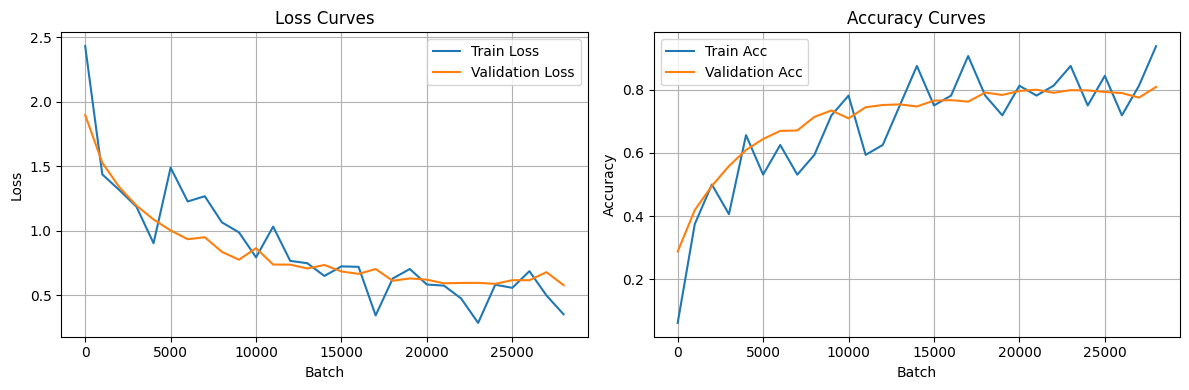

In [16]:
trainer.plot_curves()
